MovieWriter Pillow unavailable; using Pillow instead.


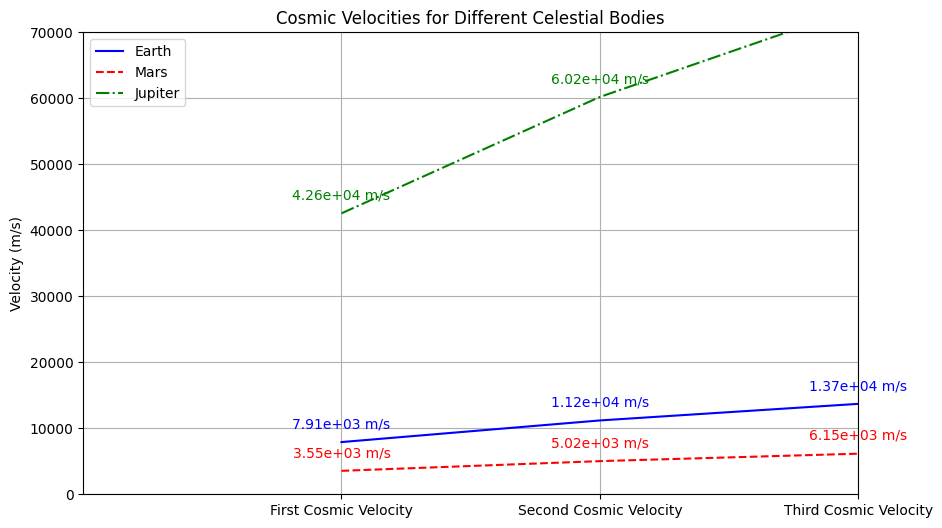

MovieWriter Pillow unavailable; using Pillow instead.


IndexError: list index out of range

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Constants
G = 6.67430e-11  # Gravitational constant in m^3 kg^-1 s^-2

# Celestial body parameters (mass in kg, radius in m)
bodies = {
    'Earth': {'mass': 5.972e24, 'radius': 6.371e6, 'color': 'blue', 'label': 'Earth', 'linestyle': '-'},
    'Mars': {'mass': 6.417e23, 'radius': 3.396e6, 'color': 'red', 'label': 'Mars', 'linestyle': '--'},
    'Jupiter': {'mass': 1.898e27, 'radius': 6.991e7, 'color': 'green', 'label': 'Jupiter', 'linestyle': '-.'},
}

# Function to calculate the first, second, and third cosmic velocities
def cosmic_velocities(mass, radius):
    v1 = np.sqrt(G * mass / radius)  # First cosmic velocity (orbital velocity)
    v2 = np.sqrt(2 * G * mass / radius)  # Second cosmic velocity (escape velocity)
    v3 = np.sqrt(3 * G * mass / radius)  # Third cosmic velocity (to escape the star system)
    return v1, v2, v3

# Calculate velocities for each celestial body
velocities = {body: cosmic_velocities(data['mass'], data['radius']) for body, data in bodies.items()}

# Prepare data for each body (for smooth animation)
x_data = [1, 2, 3]  # The positions for the x-axis (First, Second, Third Cosmic Velocity)
y_data = {body: np.array(vel) for body, vel in velocities.items()}  # Store velocities for each body

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['First Cosmic Velocity', 'Second Cosmic Velocity', 'Third Cosmic Velocity'])
ax.set_ylabel('Velocity (m/s)')
ax.set_title('Cosmic Velocities for Different Celestial Bodies')
ax.set_ylim(0, 70000)
ax.grid(True)  # Add grid for better visibility

# Initialize the plot lines for each body with styles
lines = {}
for body, data in bodies.items():
    lines[body] = ax.plot([], [], label=data['label'], color=data['color'], linestyle=data['linestyle'])[0]
ax.legend()

# Add annotations for each cosmic velocity point
annotations = {
    'Earth': [None, None, None],
    'Mars': [None, None, None],
    'Jupiter': [None, None, None],
}

# Initialize the plot (empty lines)
def init():
    for line in lines.values():
        line.set_data([], [])
    for body in annotations.values():
        for ann in body:
            if ann:
                ann.set_visible(False)
    return list(lines.values()) + [ann for body in annotations.values() for ann in body]

# Update function: called for each frame of the animation
def update(frame):
    for body, line in lines.items():
        line.set_data(x_data[:frame], y_data[body][:frame])  # Update line for the current frame

    # Add annotations dynamically
    for body, ann_list in annotations.items():
        for i in range(frame):
            if ann_list[i] is None:
                ann_list[i] = ax.annotate(
                    f"{y_data[body][i]:.2e} m/s", 
                    (x_data[i], y_data[body][i]), 
                    textcoords="offset points", 
                    xytext=(0, 10), 
                    ha='center', color=bodies[body]['color']
                )
            ann_list[i].set_visible(True)
    
    return list(lines.values()) + [ann for body in annotations.values() for ann in body]

# Create the animation with more frames for smoother transitions
ani = FuncAnimation(fig, update, frames=4, init_func=init, interval=800, repeat=False)

# Save the animation as a GIF using Pillow (without ImageMagick)
ani.save("cosmic_velocities_vivid_alternate.gif", writer="Pillow", fps=2.5)

# Show the plot
plt.show()
# Increase the number of frames for smoother animation
ani = FuncAnimation(fig, update, frames=10, init_func=init, interval=400, repeat=False)

# Save the updated animation as a GIF
ani.save("cosmic_velocities_smoother.gif", writer="Pillow", fps=5)

# Show the updated plot
plt.show()